# Results Notebook

Trains all five models, saves their results for comparison and presentation.

In [26]:
# imports
import json
from pathlib import Path
import pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time
from sklearn.model_selection import train_test_split

from src.data.loader import load_dataset
from src.data.resampler import resample
from src.models.evaluation import (
	evaluate_model_predictions,
	save_classification_report,
	build_metrics_leaderboard,
    plot_confusion_matrix
)
from src.visualization.data_visualization import (
	save_f1_chart,
	save_f1_comparison_chart,
	save_training_curves
)

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

RESULTS = Path("results")
RESULTS.mkdir(exist_ok=True)

### Loading and Resampling Data

In [2]:
# load the dataset

df = load_dataset()
print(f"Loaded {df.shape[0]} samples with {df.shape[1]} features.")

X = df.drop("Label", axis=1)
y = df["Label"]

Loading cleaned dataset from cache at cache/cleaned.parquet
Loaded 2522362 samples with 62 features.


In [ ]:
# 70% train, 30% tmp (test + val)
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Split tmp into 50% test, 50% val (=> 15% each of full dataset)
X_test, X_val, y_test, y_val = train_test_split(
    X_tmp, y_tmp, test_size=0.5, random_state=42, stratify=y_tmp
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")

print(f"Total samples: {X_train.shape[0] + X_test.shape[0] + X_val.shape[0]} samples")

Training set: 2144007 samples
Test set: 189177 samples
Validation set: 189178 samples
Total samples: 2522362 samples


In [4]:
# save test set for later
test_df = X_test.copy()
test_df["Label"] = y_test.values
test_df.to_parquet(RESULTS / "test_set.parquet", index=False)

print(f"Saved demo set to results/test_set.parquet, with {test_df.shape[0]} samples.")

Saved demo set to results/test_set.parquet, with 189177 samples.


In [5]:
# resample the training set for class imbalance
X_resampled, y_resampled = resample(X_train, y_train)

Class distribution (before vs after):
                             before   after
Label                                      
BENIGN                      1782011  500000
Bot                            1660    3000
DDoS                         108814  108814
DoS GoldenEye                  8743    8743
DoS Hulk                     146922  146922
DoS Slowhttptest               4444    4444
DoS slowloris                  4577    4577
FTP-Patator                    5043    5043
Heartbleed                        9       9
Infiltration                     31      31
PortScan                      77196   77196
SSH-Patator                    2736    2736
Web Attack - Brute Force       1249    3000
Web Attack - Sql Injection       18    2000
Web Attack - XSS                554    2000


### Model Training

In [ ]:
# logistic regression training
from src.models.logistic import train_logistic_classifier, predict_labels as lr_predict

t0 = time.time()
lr_artifacts = train_logistic_classifier(
	X_resampled,
	y_resampled,
	random_state=42,
	solver='newton-cholesky',
	max_iter=100,
	verbose=1
)
lr_train_time = time.time() - t0
print(f"Logistic regression training complete. ({lr_train_time:.1f}s)")


Newton iter=1
  Check Convergence
    1. max |gradient| 0.08634568745636242 <= 0.0001 False
Newton iter=2
  Check Convergence
    1. max |gradient| 0.08267473735874246 <= 0.0001 False
Newton iter=3
  Check Convergence
    1. max |gradient| 0.12918856934940018 <= 0.0001 False
Newton iter=4
  Check Convergence
    1. max |gradient| 0.12086462715714051 <= 0.0001 False
Newton iter=5
  Check Convergence
    1. max |gradient| 0.24067109846199902 <= 0.0001 False
Newton iter=6
  Check Convergence
    1. max |gradient| 0.2332137309172931 <= 0.0001 False
Newton iter=7
  Check Convergence
    1. max |gradient| 0.20471652505748178 <= 0.0001 False
Newton iter=8
  Check Convergence
    1. max |gradient| 0.1550733273293375 <= 0.0001 False
Newton iter=9
  Check Convergence
    1. max |gradient| 0.04797143696735969 <= 0.0001 False
Newton iter=10
  Check Convergence
    1. max |gradient| 0.03735761171820663 <= 0.0001 False
Newton iter=11
  Check Convergence
    1. max |gradient| 0.029370757186977726 <= 

                            precision    recall  f1-score   support

                    BENIGN      1.000     0.806     0.893    157236
                      DDoS      0.916     0.999     0.955      9601
                  DoS Hulk      0.827     0.998     0.905     12963
                  PortScan      0.710     0.996     0.829      6811
  Web Attack - Brute Force      0.037     0.514     0.069       111
               FTP-Patator      0.462     0.991     0.630       445
             DoS GoldenEye      0.482     0.965     0.643       771
             DoS slowloris      0.318     0.978     0.480       404
                       Bot      0.012     0.993     0.025       147
          DoS Slowhttptest      0.325     0.962     0.486       392
               SSH-Patator      0.359     0.938     0.519       241
          Web Attack - XSS      0.013     0.878     0.026        49
Web Attack - Sql Injection      0.001     1.000     0.002         2
              Infiltration      0.001     1.000

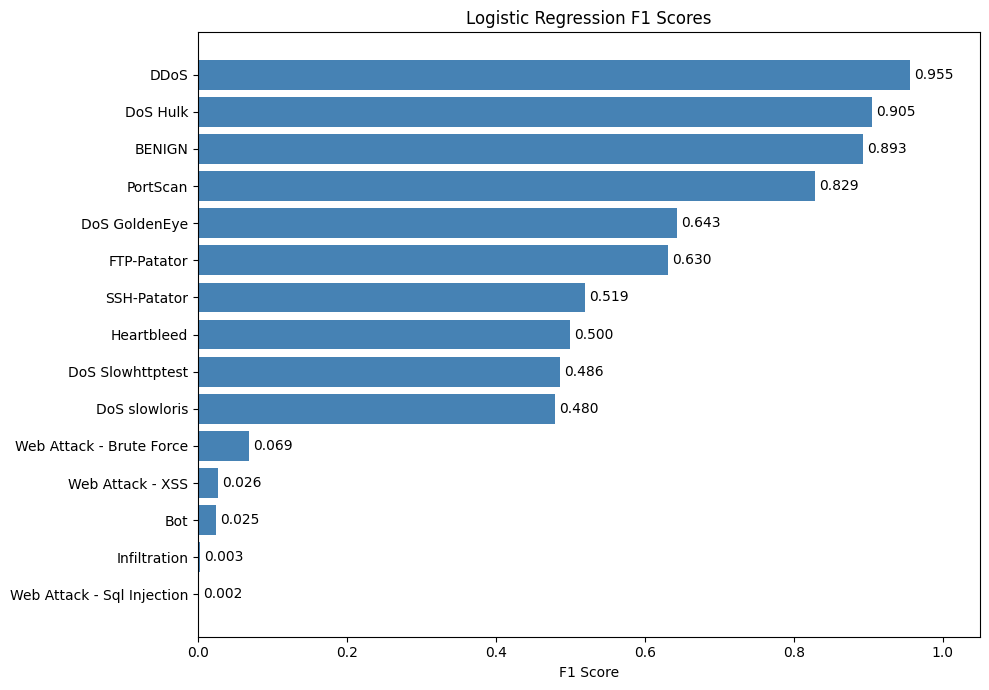

Saved results/logistic_f1_chart.png


In [7]:
# logistic regression evaluation
lr_result = evaluate_model_predictions("Logistic Regression", y_test, lr_predict(lr_artifacts, X_test))
save_classification_report(lr_result, RESULTS / "logistic_report.txt")

lr_report_dict = lr_result.classification_report_df.fillna(0).to_dict(orient="index")
(RESULTS / "logistic_report.json").write_text(json.dumps(lr_report_dict))

with open(RESULTS / "logistic_artifacts.pkl", "wb") as f:
    pickle.dump(lr_artifacts, f)

print(lr_result.classification_report_text)

save_f1_chart(
	lr_report_dict,
	title="Logistic Regression F1 Scores",
	save_path=str(RESULTS / "logistic_f1_chart.png")
)

In [23]:
# random forest training
from src.models.rf import train_rf_classifier, predict_labels as rf_predict

t0 = time.time()
rf_artifacts = train_rf_classifier(
	X_resampled,
	y_resampled,
	random_state=42,
	n_estimators=500,
	max_depth=100,
)
rf_train_time = time.time() - t0
print(f"Random forest training complete. ({rf_train_time:.1f}s)")


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 14 concurrent workers.
[Parallel(n_jobs=-1)]: Done  22 tasks      | elapsed:    3.8s
[Parallel(n_jobs=-1)]: Done 172 tasks      | elapsed:   23.0s
[Parallel(n_jobs=-1)]: Done 422 tasks      | elapsed:   54.1s


Random forest training complete. (63.9s)


[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  1.1min finished


In [24]:
depths = [tree.tree_.max_depth for tree in rf_artifacts.model.estimators_]
print(max(depths))

70


[Parallel(n_jobs=14)]: Using backend ThreadingBackend with 14 concurrent workers.
[Parallel(n_jobs=14)]: Done  22 tasks      | elapsed:    0.0s
[Parallel(n_jobs=14)]: Done 172 tasks      | elapsed:    0.2s
[Parallel(n_jobs=14)]: Done 422 tasks      | elapsed:    0.4s
[Parallel(n_jobs=14)]: Done 500 out of 500 | elapsed:    0.5s finished


                            precision    recall  f1-score   support

                    BENIGN      1.000     0.999     0.999    157236
                      DDoS      1.000     1.000     1.000      9601
                  DoS Hulk      0.997     0.999     0.998     12963
                  PortScan      0.987     0.997     0.992      6811
  Web Attack - Brute Force      0.745     0.739     0.742       111
               FTP-Patator      1.000     0.998     0.999       445
             DoS GoldenEye      0.999     0.995     0.997       771
             DoS slowloris      0.995     0.995     0.995       404
                       Bot      0.738     0.918     0.818       147
          DoS Slowhttptest      0.997     0.997     0.997       392
               SSH-Patator      1.000     0.992     0.996       241
          Web Attack - XSS      0.408     0.408     0.408        49
Web Attack - Sql Injection      0.667     1.000     0.800         2
              Infiltration      1.000     1.000

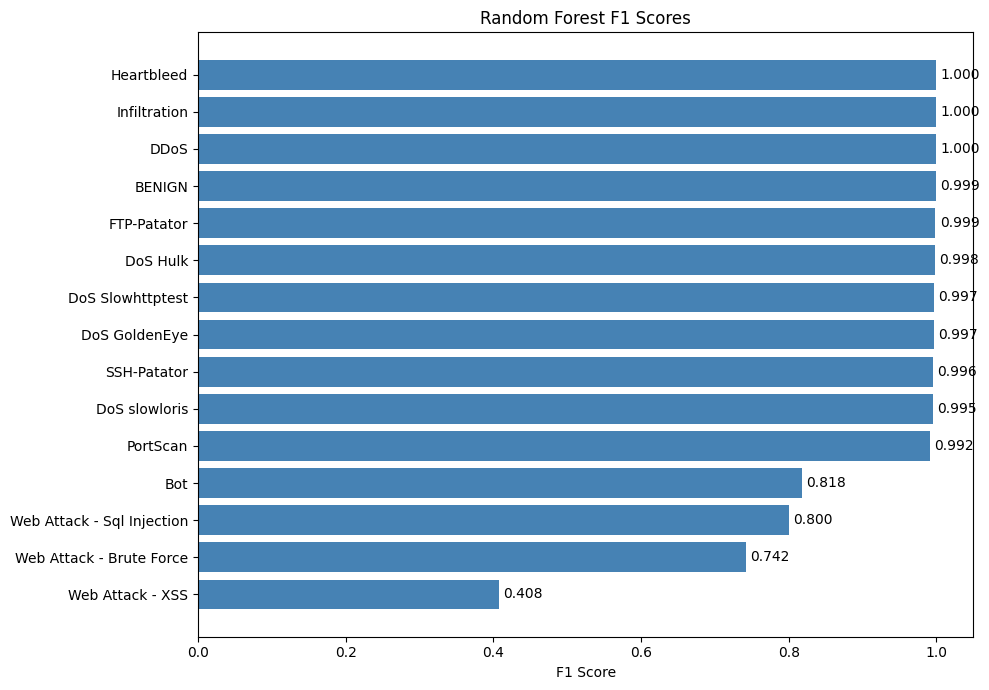

Saved results/rf_f1_chart.png


In [25]:
# rf evaluation

rf_result = evaluate_model_predictions("Random Forest", y_test, rf_predict(rf_artifacts, X_test))
save_classification_report(rf_result, RESULTS / "rf_report.txt")

rf_report_dict = rf_result.classification_report_df.fillna(0).to_dict(orient="index")
(RESULTS / "rf_report.json").write_text(json.dumps(rf_report_dict))

with open(RESULTS / "rf_artifacts.pkl", "wb") as f:
	pickle.dump(rf_artifacts, f)

print(rf_result.classification_report_text)

save_f1_chart(
	rf_report_dict,
	title="Random Forest F1 Scores",
	save_path=str(RESULTS / "rf_f1_chart.png")
)

In [ ]:
# train lightgbm classifier
from src.models.lgbm import train_lightgbm_classifier, predict_labels as lgbm_predict

t0 = time.time()
lgbm_artifacts = train_lightgbm_classifier(
	X_resampled,
	y_resampled,
	X_valid=X_val,
	y_valid=y_val,
	class_weight="balanced",
	n_estimators=500,
	early_stopping_rounds=100,
	learning_rate=0.05,
	num_leaves=63,
	random_state=42,
)
lgbm_train_time = time.time() - t0
print(f"LightGBM training complete. ({lgbm_train_time:.1f}s)")


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017334 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12511
[LightGBM] [Info] Number of data points in the train set: 868515, number of used features: 60
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050

                            precision    recall  f1-score   support

                    BENIGN      1.000     0.999     0.999    157236
                      DDoS      1.000     1.000     1.000      9601
                  DoS Hulk      0.998     1.000     0.999     12963
                  PortScan      0.987     0.999     0.993      6811
  Web Attack - Brute Force      0.734     0.622     0.673       111
               FTP-Patator      1.000     1.000     1.000       445
             DoS GoldenEye      0.995     1.000     0.997       771
             DoS slowloris      0.995     0.995     0.995       404
                       Bot      0.679     0.966     0.798       147
          DoS Slowhttptest      0.990     0.997     0.994       392
               SSH-Patator      1.000     1.000     1.000       241
          Web Attack - XSS      0.377     0.531     0.441        49
Web Attack - Sql Injection      0.667     1.000     0.800         2
              Infiltration      0.750     1.000

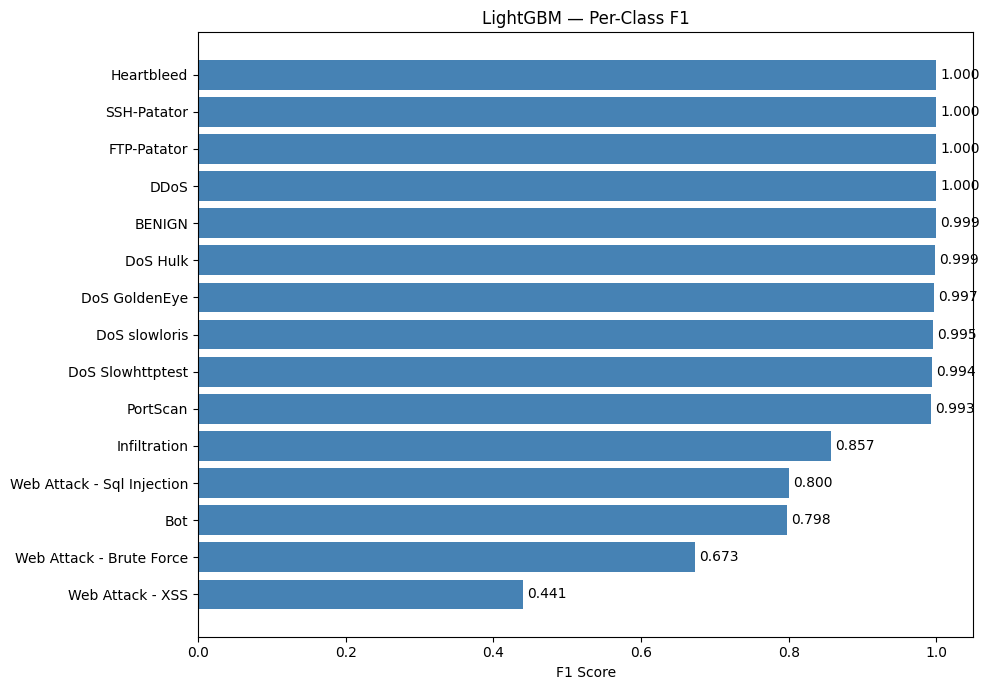

Saved results/lgbm_f1.png


In [12]:
# lightgbm evaluation
lgbm_result = evaluate_model_predictions("LightGBM", y_test, lgbm_predict(lgbm_artifacts, X_test))
save_classification_report(lgbm_result, RESULTS / "lgbm_report.txt")

lgbm_report_dict = lgbm_result.classification_report_df.fillna(0).to_dict(orient="index")
(RESULTS / "lgbm_report.json").write_text(json.dumps(lgbm_report_dict))

with open(RESULTS / "lgbm_artifacts.pkl", "wb") as f:
    pickle.dump(lgbm_artifacts, f)

print(lgbm_result.classification_report_text)

save_f1_chart(
    lgbm_report_dict,
    title="LightGBM — Per-Class F1",
    save_path=str(RESULTS / "lgbm_f1.png"),
)


In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd

def make_pca_views(X_train, X_val, X_test, n_components=0.95, random_state=42):
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_val_s = scaler.transform(X_val)
    X_test_s = scaler.transform(X_test)
    
    pca = PCA(n_components=n_components, svd_solver="full", random_state=random_state)
    X_train_p = pca.fit_transform(X_train_s)
    X_val_p = pca.transform(X_val_s)
    X_test_p = pca.transform(X_test_s)
    
    cols = [f"PC{i+1}" for i in range(X_train_p.shape[1])]
    return (
        pd.DataFrame(X_train_p, index=X_train.index, columns=cols),
        pd.DataFrame(X_val_p, index=X_val.index, columns=cols),
        pd.DataFrame(X_test_p, index=X_test.index, columns=cols),
        pca
    )

X_fit_pca, X_val_pca, X_test_pca, pca_cnn = make_pca_views(
    X_resampled, X_val, X_test, n_components=0.95, random_state=42
)
print("CNN PCA components:", pca_cnn.n_components_, "explained var:", pca_cnn.explained_variance_ratio_.sum())


CNN PCA components: 25 explained var: 0.953693901210862


In [ ]:
# mlp training PCA
# Fully-connected neural network with BatchNorm and Dropout. `StandardScaler` and `LabelEncoder` are handled internally. Uses early stopping on validation loss (patience=5). Model saved as .keras file; scaler and encoder saved separately for Streamlit.

from src.models.mlp import train_mlp_classifier, predict_labels as mlp_predict

mlp_artifacts = train_mlp_classifier(
	X_fit_pca,
	y_resampled,
	X_valid=X_val_pca,
	y_valid=y_val,
	epochs=30,
	batch_size=256,
	early_stopping_patience=10,
	learning_rate=1e-3,
	hidden_layer_sizes=(256, 128, 64),
	dropout_rate=0.15,
	random_state=42,
	verbose=1
)
print("MLP training complete.")



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 25)             │            51 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │         6,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,626 (197.76 KB)

 Trainable params: 49,679 (194.06 KB)

 Non-trainable params: 947 (3.70 KB)

None
Epoch 1/30
3393/3393 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9495 - cross_entropy: 0.1502 - loss: 0.1502 - val_accuracy: 0.9721 - val_cross_entropy: 0.0774 - val_loss: 0.0774
Epoch 2/30
3393/3393 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9651 - cross_entropy: 0.0863 - loss: 0.0863 - val_accuracy: 0.9760 - val_cross_entropy: 0.0571 - val_loss: 0.0571
Epoch 3/30
3393/3393 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9679 - cross_entropy: 0.0776 - loss: 0.0776 - val_accuracy: 0.9732 - val_cross_entropy: 0.0527 - val_loss: 0.0527
Epoch 4/30
3393/3393 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9697 - cross_entropy: 0.0730 - loss: 0.0730 - val_accuracy: 0.9725 - val_cross_entropy: 0.0558 - val_loss: 0.0558
Epoch 5/30
3393/3393 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9702 - cross_entropy: 0.0710 - loss: 0.0710 - val_accuracy: 0.9762 - val_cross_entropy: 0.0531 - val_loss: 0.0531
Epoch 6/30
3393/3393 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9712 - cross_entr

                            precision    recall  f1-score   support

                    BENIGN      0.998     0.974     0.986    157236
                      DDoS      0.997     0.988     0.993      9601
                  DoS Hulk      0.929     0.994     0.960     12963
                  PortScan      0.743     0.999     0.852      6811
  Web Attack - Brute Force      0.162     0.937     0.277       111
               FTP-Patator      0.936     0.982     0.958       445
             DoS GoldenEye      0.961     0.971     0.966       771
             DoS slowloris      0.926     0.988     0.956       404
                       Bot      0.622     0.626     0.624       147
          DoS Slowhttptest      0.904     0.962     0.932       392
               SSH-Patator      0.991     0.934     0.962       241
          Web Attack - XSS      1.000     0.020     0.040        49
Web Attack - Sql Injection      0.069     1.000     0.129         2
              Infiltration      0.000     0.000

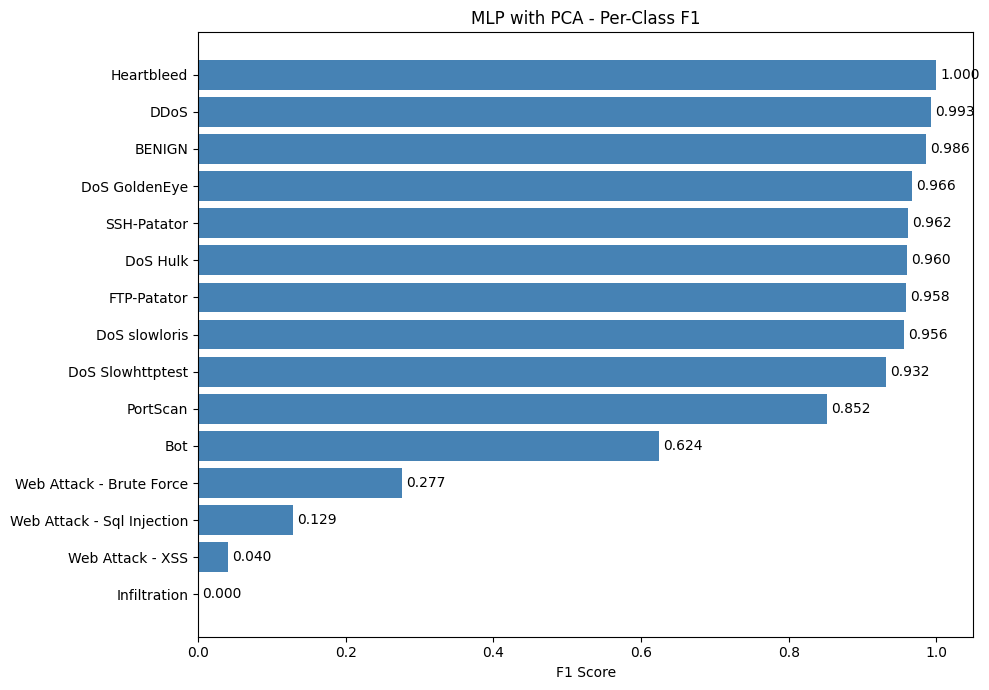

Saved results/mlp_pca_f1.png


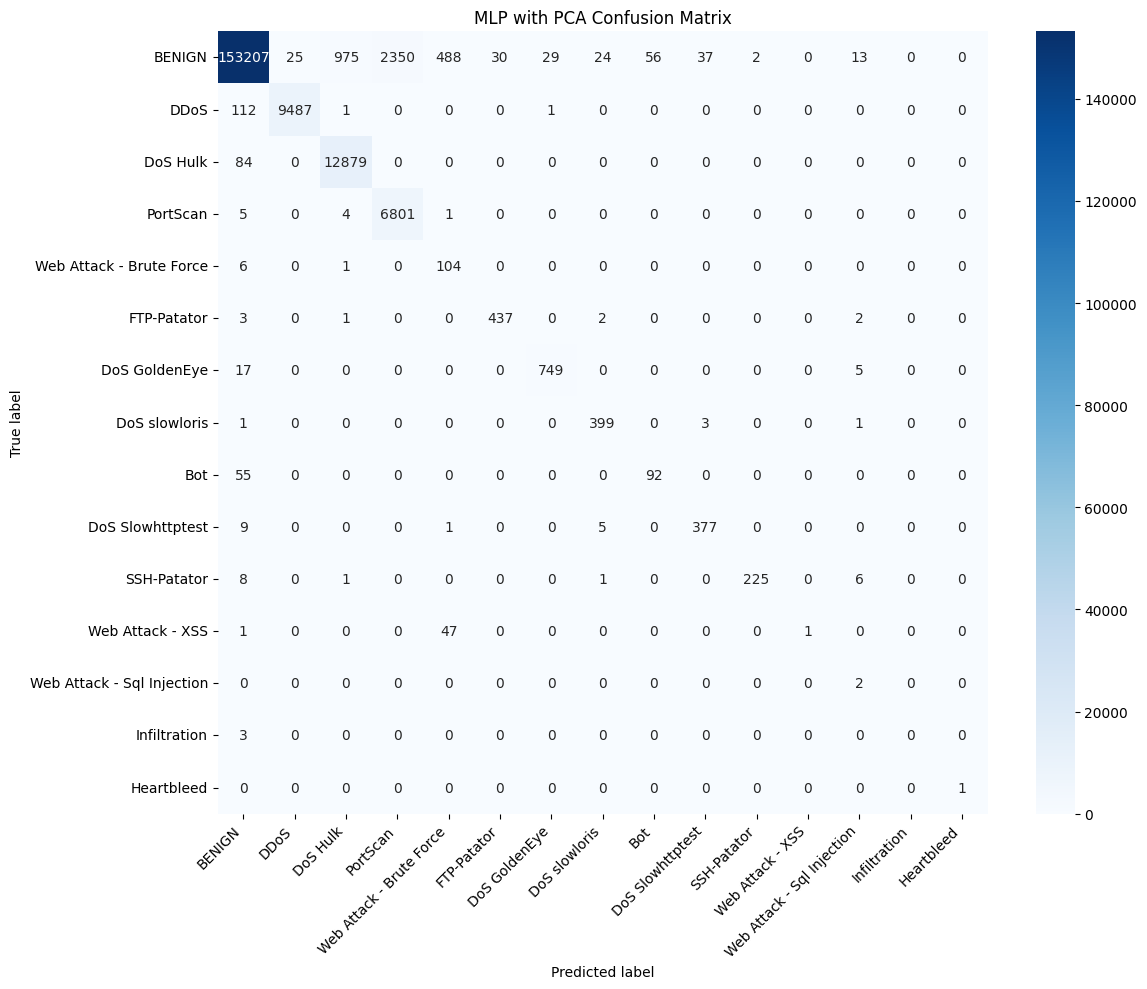

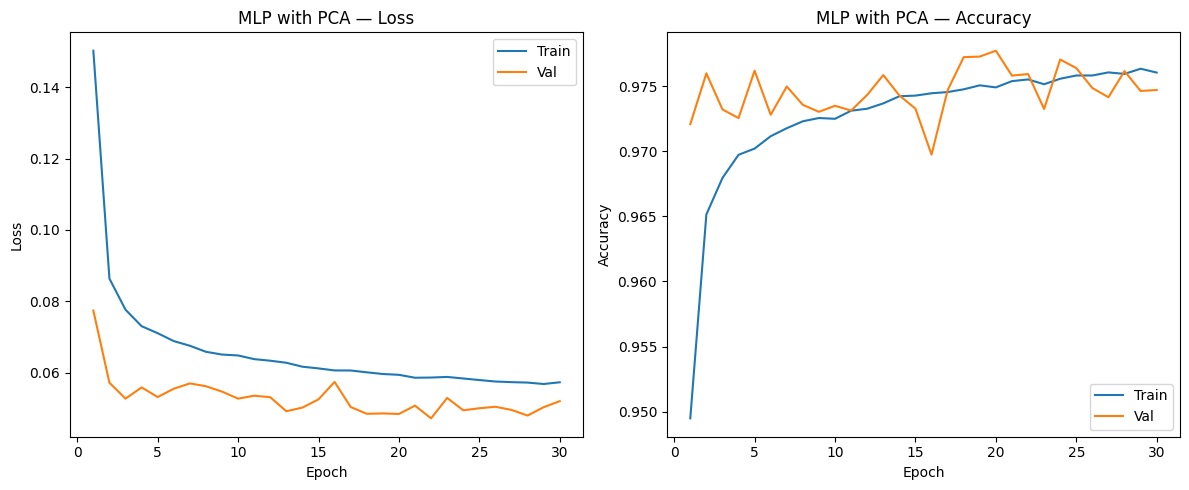

Saved results/mlp_pca_curve.png


In [ ]:
# mlp PCA evaluation
mlp_result = evaluate_model_predictions("MLP with PCA", y_test, mlp_predict(mlp_artifacts, X_test_pca))
save_classification_report(mlp_result, RESULTS / "mlp_pca_report.txt")

mlp_report_dict = mlp_result.classification_report_df.fillna(0).to_dict(orient="index")
(RESULTS / "mlp_pca_report.json").write_text(json.dumps(mlp_report_dict))

# save keras model seperately since it can't be pickled
mlp_artifacts.model.save(RESULTS / "mlp_model.keras")
with open(RESULTS / "mlp_pca_scaler.pkl", "wb") as f:
	pickle.dump(mlp_artifacts.scaler, f)
with open(RESULTS / "mlp_pca_encoder.pkl", "wb") as f:
	pickle.dump(mlp_artifacts.label_encoder, f)

print(mlp_result.classification_report_text)

save_f1_chart(
	mlp_report_dict,
	title="MLP with PCA - Per-Class F1",
	save_path=str(RESULTS / "mlp_pca_f1.png")
)

from src.models.evaluation import plot_confusion_matrix

plot_confusion_matrix(
    mlp_result,
    save_path=str(RESULTS / "mlp_pca_conf.png")
)

save_training_curves(
    mlp_artifacts.history,
    model_name="MLP with PCA",
    save_path=str(RESULTS / "mlp_pca_curve.png")
)

In [29]:
# mlp training
from src.models.mlp import train_mlp_classifier, predict_labels as mlp_predict

t0 = time.time()
mlp_artifacts = train_mlp_classifier(
	X_resampled,
	y_resampled,
	X_valid=X_val,
	y_valid=y_val,
	epochs=30,
	batch_size=256,
	early_stopping_patience=10,
	learning_rate=1e-3,
	hidden_layer_sizes=(256, 128, 64),
	dropout_rate=0.15,
	random_state=42,
	verbose=1
)
mlp_train_time = time.time() - t0
print(f"MLP training complete. ({mlp_train_time:.1f}s)")


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_3 (Normalization) │ (None, 61)             │           123 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │        15,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,914 (234.04 KB)

 Trainable params: 58,895 (230.06 KB)

 Non-trainable params: 1,019 (3.98 KB)

None
Epoch 1/30
3393/3393 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9596 - cross_entropy: 0.1139 - loss: 0.1279 - val_accuracy: 0.9742 - val_cross_entropy: 0.0551 - val_loss: 0.0551
Epoch 2/30
3393/3393 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9700 - cross_entropy: 0.0746 - loss: 0.0746 - val_accuracy: 0.9748 - val_cross_entropy: 0.0575 - val_loss: 0.0575
Epoch 3/30
3393/3393 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9734 - cross_entropy: 0.0658 - loss: 0.0658 - val_accuracy: 0.9792 - val_cross_entropy: 0.0437 - val_loss: 0.0437
Epoch 4/30
3393/3393 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9761 - cross_entropy: 0.0597 - loss: 0.0597 - val_accuracy: 0.9761 - val_cross_entropy: 0.0465 - val_loss: 0.0465
Epoch 5/30
3393/3393 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9775 - cross_entropy: 0.0563 - loss: 0.0563 - val_accuracy: 0.9701 - val_cross_entropy: 0.0569 - val_loss: 0.0569
Epoch 6/30
3393/3393 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9790 - cross_entr

                            precision    recall  f1-score   support

                    BENIGN      0.998     0.995     0.997    157236
                      DDoS      0.999     0.999     0.999      9601
                  DoS Hulk      1.000     0.985     0.992     12963
                  PortScan      0.981     0.999     0.990      6811
  Web Attack - Brute Force      0.179     0.955     0.301       111
               FTP-Patator      0.998     0.991     0.994       445
             DoS GoldenEye      0.986     0.974     0.980       771
             DoS slowloris      0.978     0.985     0.982       404
                       Bot      0.586     0.626     0.605       147
          DoS Slowhttptest      0.913     0.969     0.941       392
               SSH-Patator      0.996     0.938     0.966       241
          Web Attack - XSS      1.000     0.020     0.040        49
Web Attack - Sql Injection      0.033     1.000     0.065         2
              Infiltration      0.000     0.000

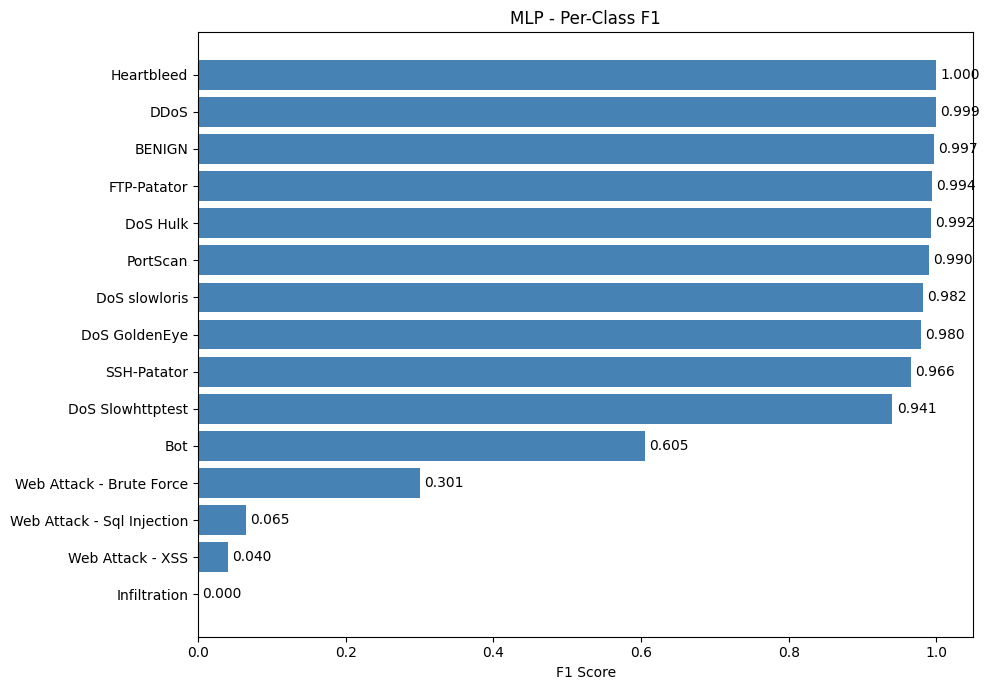

Saved results/mlp_f1.png


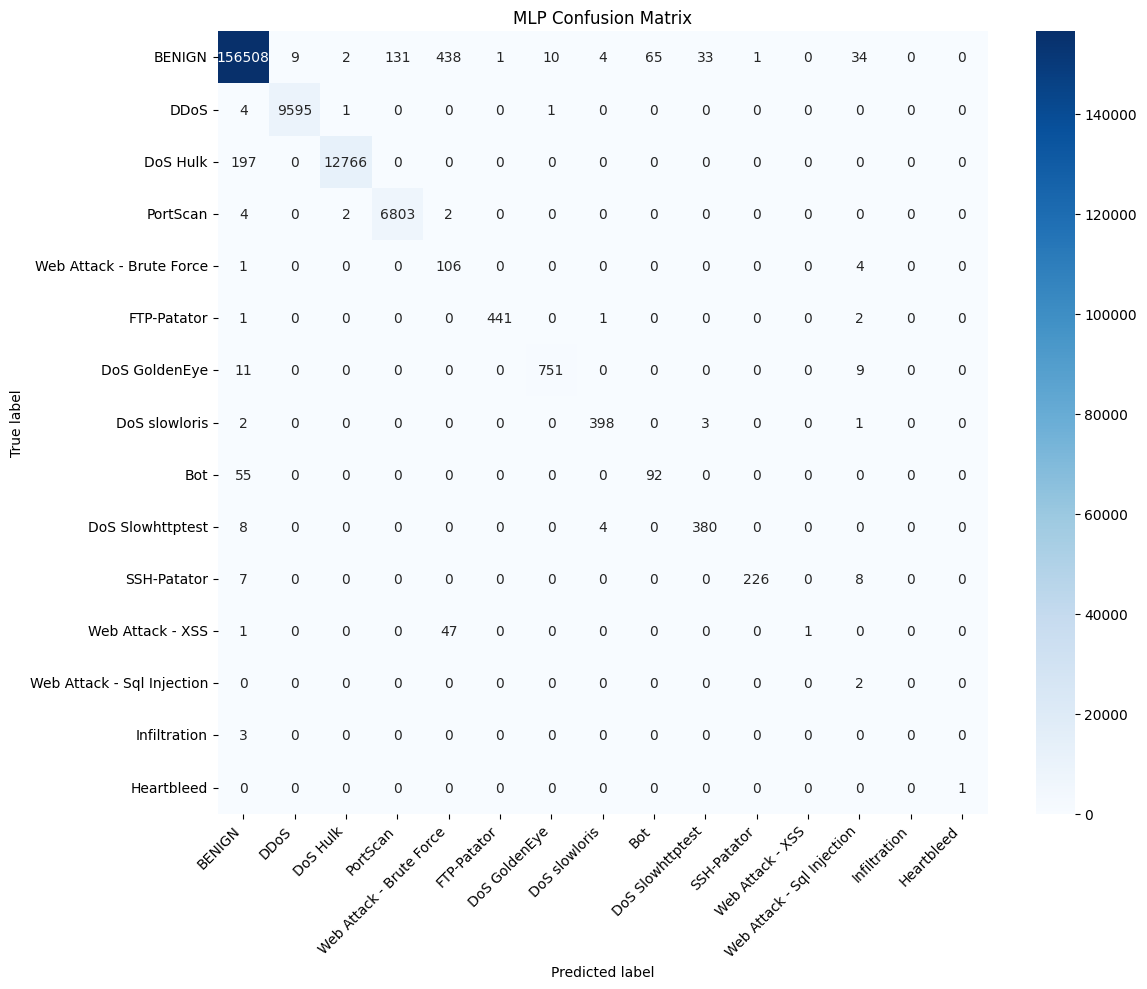

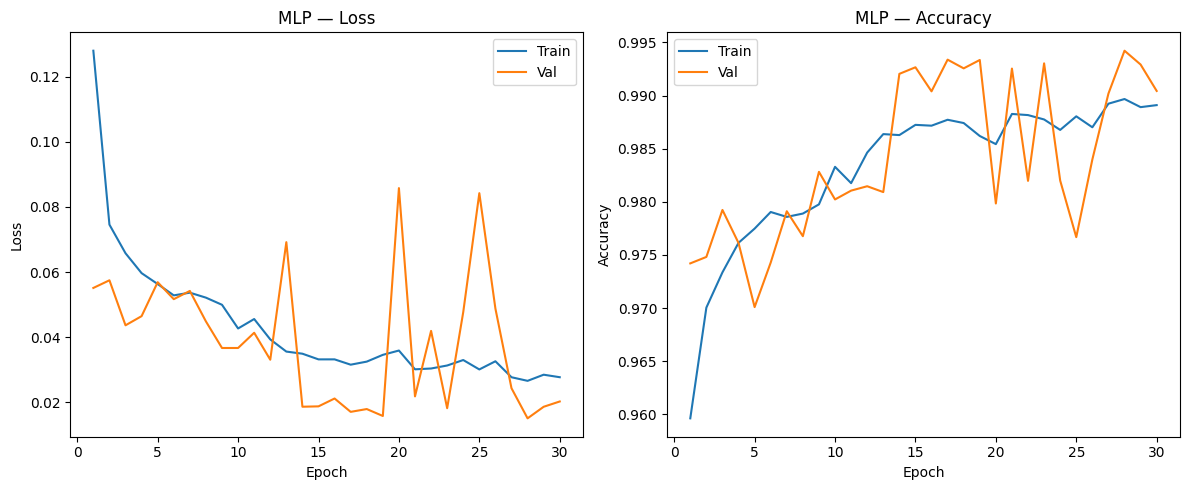

Saved results/mlp_curve.png
MLP history saved.


In [30]:
# mlp evaluation
mlp_result = evaluate_model_predictions("MLP", y_test, mlp_predict(mlp_artifacts, X_test))
save_classification_report(mlp_result, RESULTS / "mlp_report.txt")

mlp_report_dict = mlp_result.classification_report_df.fillna(0).to_dict(orient="index")
(RESULTS / "mlp_report.json").write_text(json.dumps(mlp_report_dict))

# save keras model seperately since it can't be pickled
mlp_artifacts.model.save(RESULTS / "mlp_model.keras")
with open(RESULTS / "mlp_scaler.pkl", "wb") as f:
	pickle.dump(mlp_artifacts.scaler, f)
with open(RESULTS / "mlp_encoder.pkl", "wb") as f:
	pickle.dump(mlp_artifacts.label_encoder, f)

print(mlp_result.classification_report_text)

save_f1_chart(
	mlp_report_dict,
	title="MLP - Per-Class F1",
	save_path=str(RESULTS / "mlp_f1.png")
)

from src.models.evaluation import plot_confusion_matrix

plot_confusion_matrix(
    mlp_result,
    save_path=str(RESULTS / "mlp_conf.png")
)

save_training_curves(
    mlp_artifacts.history,
    model_name="MLP",
    save_path=str(RESULTS / "mlp_curve.png")
)

# save training history for interactive Plotly display in Streamlit
(RESULTS / "mlp_history.json").write_text(
    json.dumps({k: [float(v) for v in vs] for k, vs in mlp_artifacts.history.items()})
)
print("MLP history saved.")


In [ ]:
# cnn training
from src.models.cnn import train_cnn_classifier, predict_labels as cnn_predict

t0 = time.time()
cnn_artifacts = train_cnn_classifier(
	X_resampled,
	y_resampled,
	X_valid=X_val,
	y_valid=y_val,
	epochs=30,
	batch_size=128,
	early_stopping_patience=10,
	learning_rate=1e-3,
	verbose=1,
	conv_filters=(64,32),
	dense_units=64,
	dropout_rate=0.0,
)
cnn_train_time = time.time() - t0
print(f"CNN training complete. ({cnn_train_time:.1f}s)")


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 61, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 30, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 15, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 480)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │        30,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,191 (149.18 KB)

 Trainable params: 38,191 (149.18 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/30
6786/6786 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.9608 - cross entropy: 0.1156 - loss: 0.1156 - val_accuracy: 0.9758 - val_cross entropy: 0.0505 - val_loss: 0.0505
Epoch 2/30
6786/6786 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.9756 - cross entropy: 0.0630 - loss: 0.0630 - val_accuracy: 0.9785 - val_cross entropy: 0.0443 - val_loss: 0.0443
Epoch 3/30
6786/6786 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.9785 - cross entropy: 0.0537 - loss: 0.0537 - val_accuracy: 0.9802 - val_cross entropy: 0.0403 - val_loss: 0.0403
Epoch 4/30
6786/6786 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.9796 - cross entropy: 0.0493 - loss: 0.0493 - val_accuracy: 0.9807 - val_cross entropy: 0.0382 - val_loss: 0.0382
Epoch 5/30
6786/6786 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.9802 - cross entropy: 0.0481 - loss: 0.0481 - val_accuracy: 0.9805 - val_cross entropy: 0.0400 - val_loss: 0.0400
Epoch 6/30
6786/6786 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.9807 - cros

                            precision    recall  f1-score   support

                    BENIGN      0.999     0.997     0.998    157236
                      DDoS      1.000     0.999     0.999      9601
                  DoS Hulk      0.989     0.998     0.993     12963
                  PortScan      0.987     0.999     0.993      6811
  Web Attack - Brute Force      0.404     0.757     0.527       111
               FTP-Patator      1.000     0.991     0.995       445
             DoS GoldenEye      0.993     0.982     0.988       771
             DoS slowloris      0.980     0.995     0.988       404
                       Bot      0.540     0.735     0.622       147
          DoS Slowhttptest      0.917     0.982     0.948       392
               SSH-Patator      0.975     0.954     0.964       241
          Web Attack - XSS      0.328     0.429     0.372        49
Web Attack - Sql Injection      0.077     1.000     0.143         2
              Infiltration      0.750     1.000

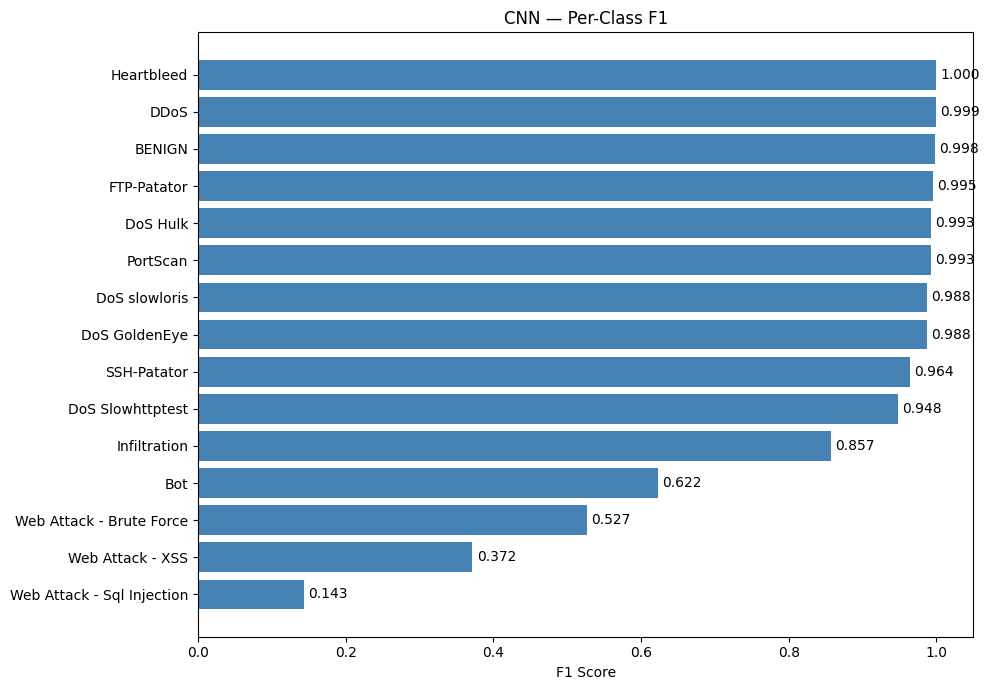

Saved results/cnn_f1.png


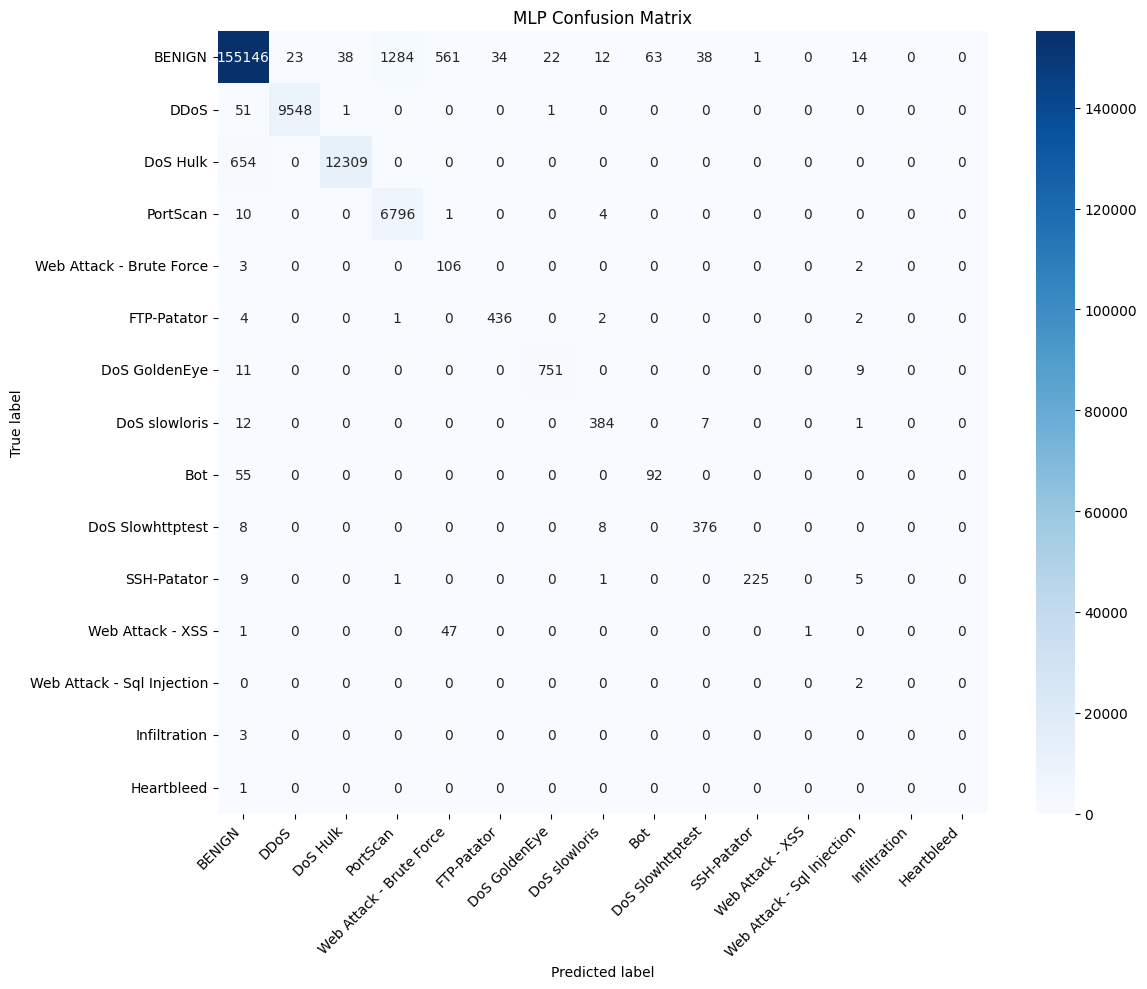

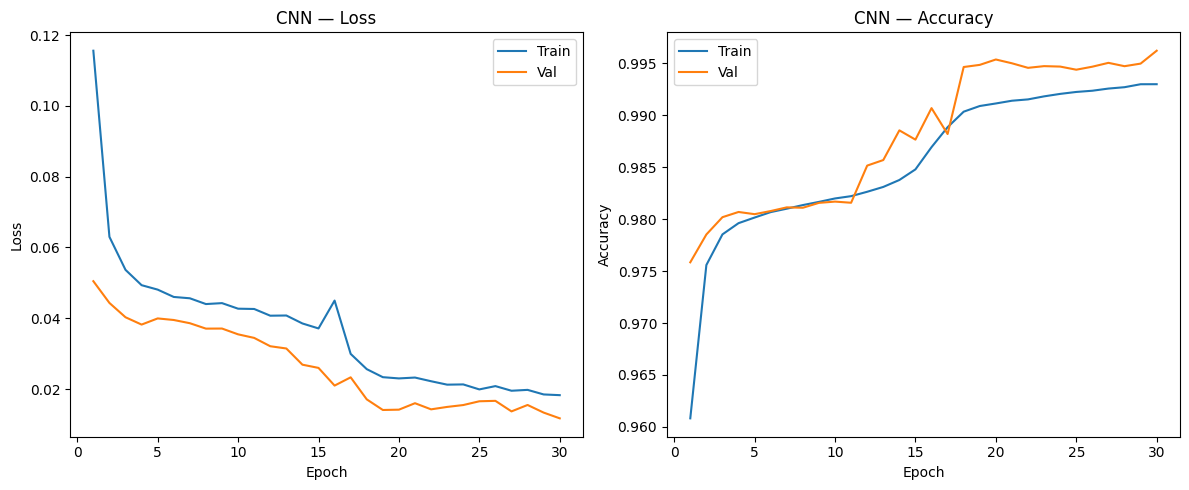

Saved results/cnn_curve.png
CNN history saved.


In [19]:


cnn_result = evaluate_model_predictions("CNN", y_test, cnn_predict(cnn_artifacts, X_test))
save_classification_report(cnn_result, RESULTS / "cnn_report.txt")

cnn_report_dict = cnn_result.classification_report_df.fillna(0).to_dict(orient="index")
(RESULTS / "cnn_report.json").write_text(json.dumps(cnn_report_dict))

cnn_artifacts.model.save(RESULTS / "cnn_model.keras")
with open(RESULTS / "cnn_scaler.pkl", "wb") as f:
    pickle.dump(cnn_artifacts.scaler, f)
with open(RESULTS / "cnn_encoder.pkl", "wb") as f:
    pickle.dump(cnn_artifacts.label_encoder, f)

print(cnn_result.classification_report_text)

save_f1_chart(
    cnn_report_dict,
    title="CNN — Per-Class F1",
    save_path=str(RESULTS / "cnn_f1.png"),
)

from src.models.evaluation import plot_confusion_matrix

plot_confusion_matrix(
    mlp_result,
    save_path=str(RESULTS / "cnn_conf.png")
)

save_training_curves(
    cnn_artifacts.history,
    model_name="CNN",
    save_path=str(RESULTS / "cnn_curve.png")
)

# save training history for interactive Plotly display in Streamlit
(RESULTS / "cnn_history.json").write_text(
    json.dumps({k: [float(v) for v in vs] for k, vs in cnn_artifacts.history.items()})
)
print("CNN history saved.")


In [20]:
# collect and save training times for all 5 models
training_times = {
    "Logistic Regression": round(lr_train_time, 1),
    "Random Forest": round(rf_train_time, 1),
    "LightGBM": round(lgbm_train_time, 1),
    "MLP": round(mlp_train_time, 1),
    "CNN": round(cnn_train_time, 1),
}
(RESULTS / "training_times.json").write_text(json.dumps(training_times))
print("Training times saved:")
for name, t in training_times.items():
    print(f"  {name}: {t}s")


Training times saved:
  Logistic Regression: 241.3s
  Random Forest: 25.3s
  LightGBM: 80.6s
  MLP: 89.2s
  CNN: 330.7s


In [21]:
# cnn training
# 1D convolutional neural network. Uses early stopping on validation loss (patience=10). Model saved as .keras file; scaler and encoder saved separately for Streamlit.

from src.models.cnn import train_cnn_classifier, predict_labels as cnn_predict


cnn_artifacts = train_cnn_classifier(
	X_fit_pca,
	y_resampled,
	X_valid=X_val_pca,
	y_valid=y_val,
	epochs=30,
	batch_size=256,
	early_stopping_patience=10,
	learning_rate=1e-3,
	verbose=1,
    conv_filters=(64,32),
    dense_units=64,
    dropout_rate=0.0,
)
print("CNN training complete.")

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 25, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 12, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 6, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,759 (77.18 KB)

 Trainable params: 19,759 (77.18 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/30
3393/3393 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9535 - cross entropy: 0.1460 - loss: 0.1753 - val_accuracy: 0.9707 - val_cross entropy: 0.0794 - val_loss: 0.0794
Epoch 2/30
3393/3393 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9660 - cross entropy: 0.0894 - loss: 0.0894 - val_accuracy: 0.9727 - val_cross entropy: 0.0718 - val_loss: 0.0718
Epoch 3/30
3393/3393 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9689 - cross entropy: 0.0792 - loss: 0.0792 - val_accuracy: 0.9738 - val_cross entropy: 0.0648 - val_loss: 0.0648
Epoch 4/30
3393/3393 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9703 - cross entropy: 0.0737 - loss: 0.0737 - val_accuracy: 0.9743 - val_cross entropy: 0.0615 - val_loss: 0.0615
Epoch 5/30
3393/3393 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9717 - cross entropy: 0.0692 - loss: 0.0692 - val_accuracy: 0.9733 - val_cross entropy: 0.0581 - val_loss: 0.0581
Epoch 6/30
3393/3393 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9724 - cross entr

                            precision    recall  f1-score   support

                    BENIGN      0.999     0.979     0.988    157236
                      DDoS      0.998     0.999     0.998      9601
                  DoS Hulk      0.973     0.991     0.982     12963
                  PortScan      0.743     0.998     0.852      6811
  Web Attack - Brute Force      0.196     0.640     0.300       111
               FTP-Patator      0.978     0.984     0.981       445
             DoS GoldenEye      0.976     0.984     0.980       771
             DoS slowloris      0.928     0.993     0.959       404
                       Bot      0.605     0.626     0.615       147
          DoS Slowhttptest      0.906     0.954     0.929       392
               SSH-Patator      0.987     0.934     0.959       241
          Web Attack - XSS      0.120     0.673     0.203        49
Web Attack - Sql Injection      0.021     0.500     0.040         2
              Infiltration      0.200     0.667

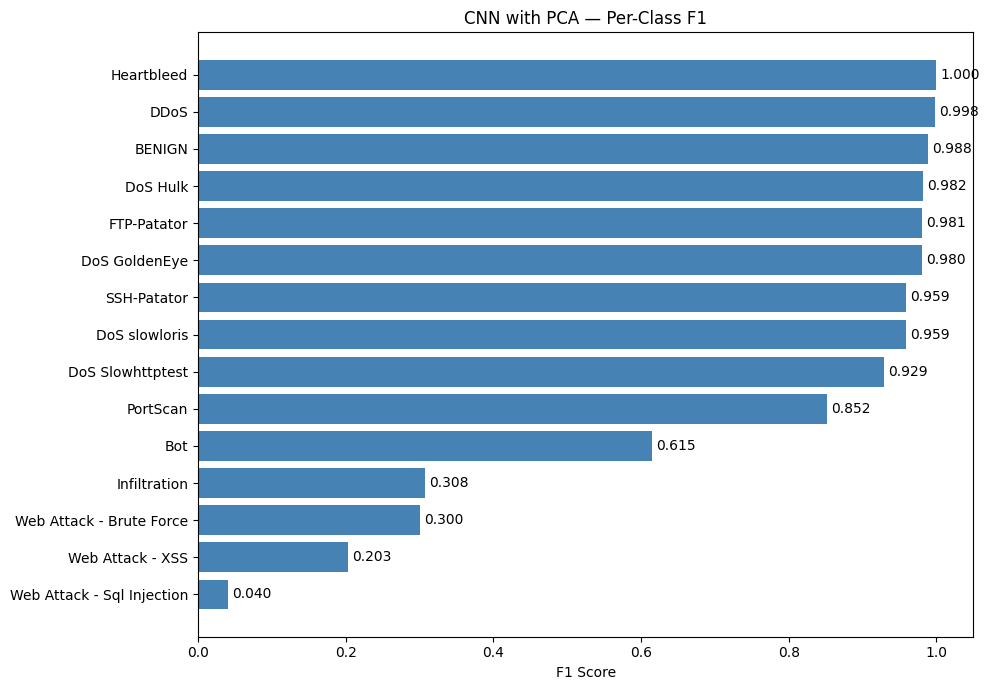

Saved results/cnn_pca_f1.png


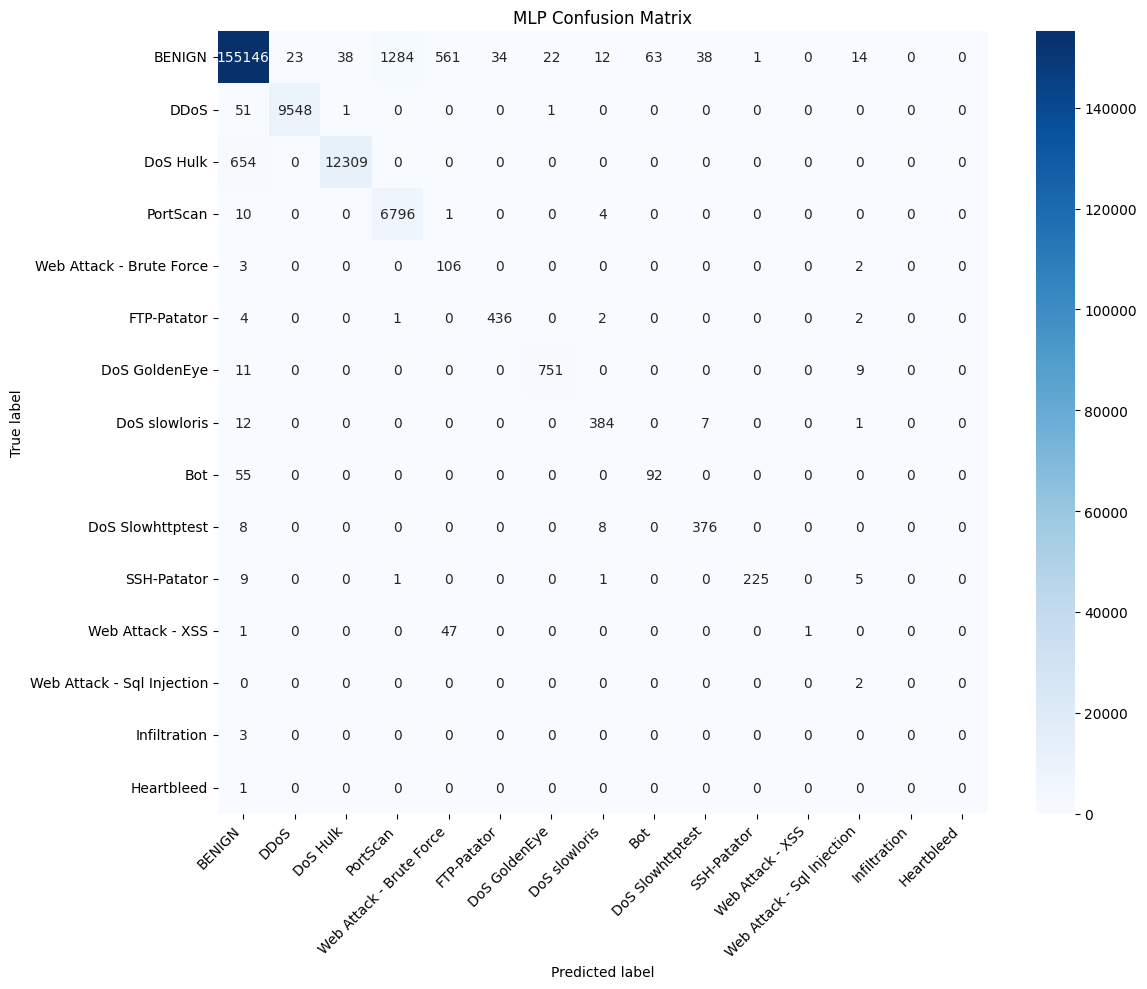

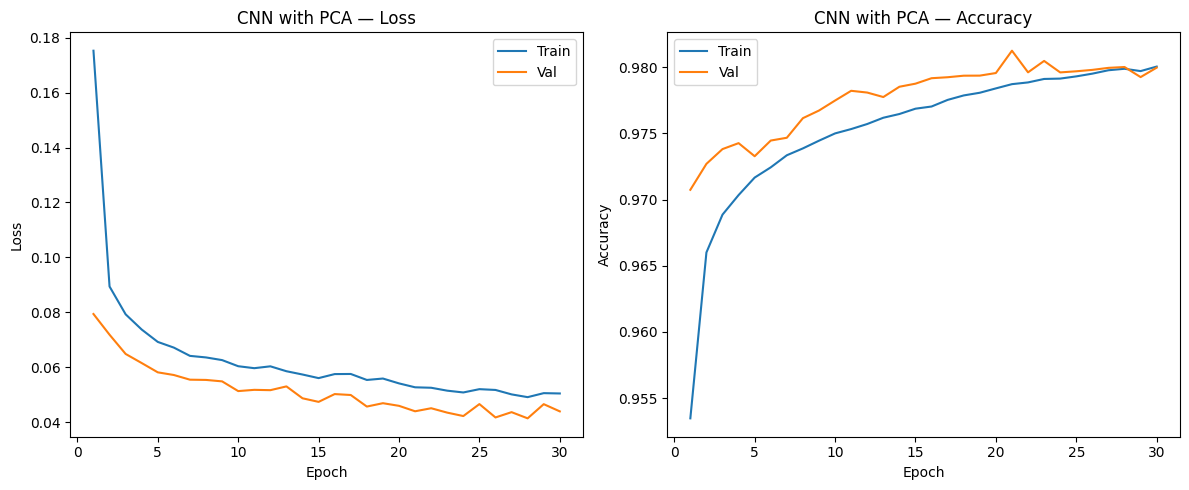

Saved results/cnn_pca_curve.png


In [27]:
cnn_result = evaluate_model_predictions("CNN with PCA", y_test, cnn_predict(cnn_artifacts, X_test_pca))
save_classification_report(cnn_result, RESULTS / "cnn_pca_report.txt")

cnn_report_dict = cnn_result.classification_report_df.fillna(0).to_dict(orient="index")
(RESULTS / "cnn_pca_report.json").write_text(json.dumps(cnn_report_dict))

cnn_artifacts.model.save(RESULTS / "cnn_pca_model.keras")
with open(RESULTS / "cnn_pca_scaler.pkl", "wb") as f:
    pickle.dump(cnn_artifacts.scaler, f)
with open(RESULTS / "cnn_pca_encoder.pkl", "wb") as f:
    pickle.dump(cnn_artifacts.label_encoder, f)

print(cnn_result.classification_report_text)

save_f1_chart(
    cnn_report_dict,
    title="CNN with PCA — Per-Class F1",
    save_path=str(RESULTS / "cnn_pca_f1.png"),
)

from src.models.evaluation import plot_confusion_matrix

plot_confusion_matrix(
    mlp_result,
    save_path=str(RESULTS / "cnn_pca_conf.png")
)

save_training_curves(
    cnn_artifacts.history,
    model_name="CNN with PCA",
    save_path=str(RESULTS / "cnn_pca_curve.png")
)

### Model Comparisons